In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import PolynomialFeatures

In [3]:

data = pd.DataFrame({
    'RAM': [4, 6, 8, 12, 16],
    'Storage': [64, 128, 256, 256, 512]
})

poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(data)

print(poly_features)

[[1.00000e+00 4.00000e+00 6.40000e+01 1.60000e+01 2.56000e+02 4.09600e+03]
 [1.00000e+00 6.00000e+00 1.28000e+02 3.60000e+01 7.68000e+02 1.63840e+04]
 [1.00000e+00 8.00000e+00 2.56000e+02 6.40000e+01 2.04800e+03 6.55360e+04]
 [1.00000e+00 1.20000e+01 2.56000e+02 1.44000e+02 3.07200e+03 6.55360e+04]
 [1.00000e+00 1.60000e+01 5.12000e+02 2.56000e+02 8.19200e+03 2.62144e+05]]


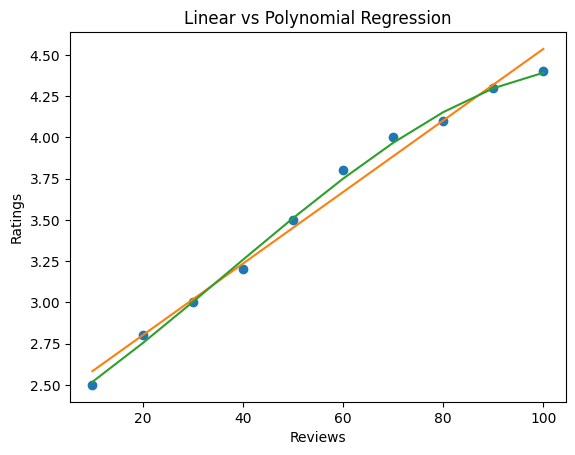

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

reviews = np.array([10,20,30,40,50,60,70,80,90,100]).reshape(-1,1)
ratings = np.array([2.5,2.8,3.0,3.2,3.5,3.8,4.0,4.1,4.3,4.4])

linear = LinearRegression()
linear.fit(reviews, ratings)

poly = PolynomialFeatures(degree=3)
reviews_poly = poly.fit_transform(reviews)

poly_model = LinearRegression()
poly_model.fit(reviews_poly, ratings)

plt.plot(reviews, ratings, 'o')
plt.plot(reviews, linear.predict(reviews))
plt.plot(reviews, poly_model.predict(reviews_poly))

plt.xlabel("Reviews")
plt.ylabel("Ratings")
plt.title("Linear vs Polynomial Regression")
plt.show()

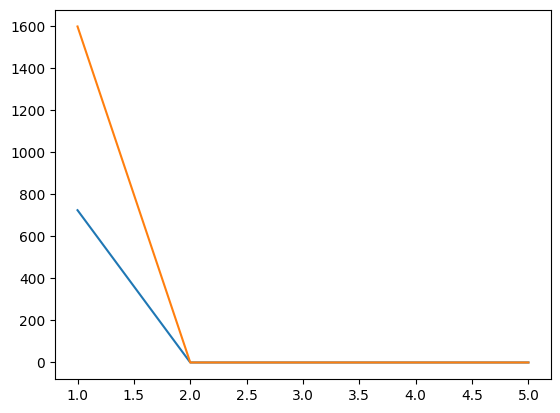

In [8]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

x = np.arange(1,21).reshape(-1,1)
y = x.flatten()**2

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

train=[]
test=[]

for i in range(1,6):
    poly = PolynomialFeatures(i)

    x1 = poly.fit_transform(x_train)
    x2 = poly.transform(x_test)

    model = LinearRegression()
    model.fit(x1,y_train)

    train.append(mean_squared_error(y_train,model.predict(x1)))
    test.append(mean_squared_error(y_test,model.predict(x2)))

plt.plot(range(1,6),train)
plt.plot(range(1,6),test)
plt.show()

In [11]:

from sklearn.linear_model import LinearRegression, Ridge

x = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([10,20,30,40,50])

poly = PolynomialFeatures(3)
x_poly = poly.fit_transform(x)

model1 = LinearRegression()
model1.fit(x_poly, y)

model2 = Ridge()
model2.fit(x_poly, y)

print("Without Regularization:", mean_squared_error(y, model1.predict(x_poly)))
print("With Regularization:", mean_squared_error(y, model2.predict(x_poly)))

Without Regularization: 5.82116239180689e-27
With Regularization: 0.5781448535062792


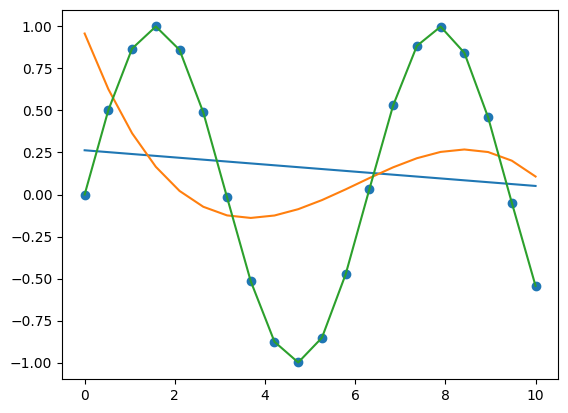

In [10]:


x = np.linspace(0,10,20).reshape(-1,1)
y = np.sin(x)

for i in [1,3,10]:
    poly = PolynomialFeatures(i)
    x_poly = poly.fit_transform(x)

    model = LinearRegression()
    model.fit(x_poly, y)

    plt.plot(x, model.predict(x_poly))

plt.scatter(x, y)
plt.show()